# Facebook Ad Campaign Performance & Budget Reallocation

**Business question:** Across three Facebook ad campaigns, which audiences convert most cost-effectively, and where should budget move to get more approved conversions for the same spend?

**Data:** [Sales Conversion Optimization (Kaggle)](https://www.kaggle.com/datasets/loveall/clicks-conversion-tracking), 1,143 ads across 3 campaigns, with age, gender, interest, impressions, clicks, spend and conversions. The dataset does not state the currency, so spend is reported as plain numbers.

**Metrics used**
| Metric | Formula | What it tells you |
|---|---|---|
| CTR | clicks ÷ impressions | how often people who see the ad click it |
| CPC | spend ÷ clicks | cost of one click |
| CPM | spend ÷ impressions × 1,000 | cost of 1,000 impressions |
| Approval rate | approved conversions ÷ total conversions | share of conversions that were approved |
| **CPA** | spend ÷ approved conversions | **cost of one approved conversion (main efficiency metric)** |

There is no revenue column, so ROAS cannot be calculated; CPA is used instead.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ACCENT, MUTED, BAD = '#2E5C8A', '#B8C4CE', '#B4483C'
df = pd.read_csv('KAG_conversion_data.csv')
df = df.rename(columns={'xyz_campaign_id': 'campaign'})
print(df.shape)
df.head()

(1143, 11)


,ad_id,campaign,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,0
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,0
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,1


## 1. Data checks

In [2]:
checks = pd.Series({
    'Missing values': int(df.isna().sum().sum()),
    'Duplicate rows': int(df.duplicated().sum()),
    'Duplicate ad IDs': int(df['ad_id'].duplicated().sum()),
    'Clicks > impressions': int((df['Clicks'] > df['Impressions']).sum()),
    'Approved > total conversions': int((df['Approved_Conversion'] > df['Total_Conversion']).sum()),
    'Ads with 0 clicks and 0 spend': int(((df['Clicks'] == 0) & (df['Spent'] == 0)).sum()),
    '...of which still record conversions': int(((df['Clicks'] == 0) & (df['Spent'] == 0) & (df['Total_Conversion'] > 0)).sum()),
})
checks.to_frame('count')

,count
Missing values,0
Duplicate rows,0
Duplicate ad IDs,0
Clicks > impressions,0
Approved > total conversions,0
Ads with 0 clicks and 0 spend,207
...of which still record conversions,204


The structural checks pass. One anomaly: **207 ads show impressions but 0 clicks and 0 spend, and 204 of them still record conversions.** These are most likely conversions credited to an ad after someone only *viewed* it (view-through attribution), but the dataset does not say. They are kept, because dropping them would remove real conversions, and they have no effect on spend-based metrics. In a real job, this is the kind of thing to confirm with the campaign team before reporting.

In [3]:
def metrics(g):
    s = g[['Impressions', 'Clicks', 'Spent', 'Total_Conversion', 'Approved_Conversion']].sum()
    return pd.Series({
        'ads': len(g), 'impressions': s['Impressions'], 'clicks': s['Clicks'], 'spend': s['Spent'],
        'conversions': s['Total_Conversion'], 'approved': s['Approved_Conversion'],
        'CTR': s['Clicks'] / s['Impressions'], 'CPC': s['Spent'] / s['Clicks'],
        'CPM': s['Spent'] / s['Impressions'] * 1000,
        'approval_rate': s['Approved_Conversion'] / s['Total_Conversion'],
        'CPA': s['Spent'] / s['Approved_Conversion'],
        'spend_share': s['Spent'] / df['Spent'].sum(),
        'approved_share': s['Approved_Conversion'] / df['Approved_Conversion'].sum(),
    })

fmt = {'ads': '{:,.0f}', 'impressions': '{:,.0f}', 'clicks': '{:,.0f}', 'spend': '{:,.0f}', 'conversions': '{:,.0f}', 'approved': '{:,.0f}',
       'CTR': '{:.3%}', 'CPC': '{:.2f}', 'CPM': '{:.2f}', 'approval_rate': '{:.0%}', 'CPA': '{:.2f}',
       'spend_share': '{:.0%}', 'approved_share': '{:.0%}'}

## 2. Overall performance (the weekly-report KPI row)

In [4]:
overall = metrics(df)
overall.to_frame('all campaigns').T.style.format(fmt)

,ads,impressions,clicks,spend,conversions,approved,CTR,CPC,CPM,approval_rate,CPA,spend_share,approved_share
all campaigns,"1,143","213,434,828","38,165","58,705","3,264","1,079",0.018%,1.54,0.28,33%,54.41,100%,100%


## 3. Campaign comparison

In [5]:
camp = df.groupby('campaign').apply(metrics)
camp.style.format(fmt)

,ads,impressions,clicks,spend,conversions,approved,CTR,CPC,CPM,approval_rate,CPA,spend_share,approved_share
campaign,,,,,,,,,,,,,
916,54,"482,925",113,150,58,24,0.023%,1.32,0.31,41%,6.24,0%,2%
936,464,"8,128,187","1,984","2,893",537,183,0.024%,1.46,0.36,34%,15.81,5%,17%
1178,625,"204,823,716","36,068","55,662","2,669",872,0.018%,1.54,0.27,33%,63.83,95%,81%


Campaign 1178 takes **95% of spend** but delivers 81% of approved conversions, at a CPA about 4× campaign 936's. The two smaller campaigns spent far less, so their low CPAs may not hold at 1178's scale; the audience breakdown below is a fairer place to look for savings, because it compares segments **inside** the same campaign.

## 4. Audience comparison: age and gender

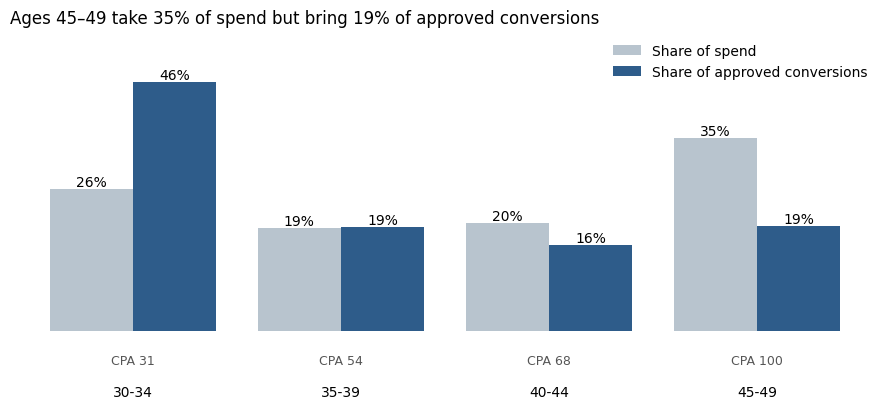

,ads,impressions,clicks,spend,conversions,approved,CTR,CPC,CPM,approval_rate,CPA,spend_share,approved_share
age,,,,,,,,,,,,,
30-34,426,"67,993,019","9,483","15,252","1,431",494,0.014%,1.61,0.22,35%,30.88,26%,46%
35-39,248,"42,104,644","7,094","11,112",626,207,0.017%,1.57,0.26,33%,53.68,19%,19%
40-44,210,"39,604,307","7,736","11,590",523,170,0.020%,1.50,0.29,33%,68.17,20%,16%
45-49,259,"63,732,858","13,852","20,751",684,208,0.022%,1.50,0.33,30%,99.76,35%,19%


In [6]:
age = df.groupby('age').apply(metrics)
fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(age))
ax.bar(x - 0.2, age['spend_share'], 0.4, color=MUTED, label='Share of spend')
ax.bar(x + 0.2, age['approved_share'], 0.4, color=ACCENT, label='Share of approved conversions')
for i, (s, a, cpa) in enumerate(zip(age['spend_share'], age['approved_share'], age['CPA'])):
    ax.text(i - 0.2, s, f'{s:.0%}', ha='center', va='bottom')
    ax.text(i + 0.2, a, f'{a:.0%}', ha='center', va='bottom')
    ax.text(i, -0.06, f'CPA {cpa:.0f}', ha='center', fontsize=9, color='#555')
ax.set_xticks(x, age.index); ax.set_yticks([]); ax.set_ylim(-0.09, 0.55)
ax.set_title(f"Ages 45–49 take {age.loc['45-49','spend_share']:.0%} of spend but bring {age.loc['45-49','approved_share']:.0%} of approved conversions", loc='left')
ax.legend(frameon=False, loc='upper right'); ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False); ax.tick_params(axis='x', length=0)
plt.tight_layout(); plt.show()
age.style.format(fmt)

In [7]:
gender = df.groupby('gender').apply(metrics)
gender.style.format(fmt)

,ads,impressions,clicks,spend,conversions,approved,CTR,CPC,CPM,approval_rate,CPA,spend_share,approved_share
gender,,,,,,,,,,,,,
F,551,"114,862,847","23,878","34,503","1,644",495,0.021%,1.44,0.30,30%,69.70,59%,46%
M,592,"98,571,981","14,287","24,203","1,620",584,0.014%,1.69,0.25,36%,41.44,41%,54%


Within the largest campaign (1178), age × gender shows where the money goes least efficiently:

In [8]:
big = df[df['campaign'] == 1178]
seg = big.groupby(['age', 'gender']).apply(metrics)[['spend', 'approved', 'CPA', 'CTR', 'spend_share']]
seg['spend_share'] = seg['spend'] / big['Spent'].sum()
seg.sort_values('CPA').style.format(fmt)

## 5. Budget reallocation scenario

In [9]:
SHIFT = 0.25  # move 25% of the 45–49 budget to 30–34
moved = age.loc['45-49', 'spend'] * SHIFT
lost = moved / age.loc['45-49', 'CPA']
gained = moved / age.loc['30-34', 'CPA']
net = gained - lost
print(f"Budget moved:                 {moved:,.0f}")
print(f"Approved conversions lost:    {lost:,.0f}  (at 45–49 CPA {age.loc['45-49','CPA']:.2f})")
print(f"Approved conversions gained:  {gained:,.0f}  (at 30–34 CPA {age.loc['30-34','CPA']:.2f})")
print(f"Net change:                   +{net:,.0f} approved conversions (+{net / overall['approved']:.0%}) at the same total spend")

Budget moved:                 5,188
Approved conversions lost:    52  (at 45–49 CPA 99.76)
Approved conversions gained:  168  (at 30–34 CPA 30.88)
Net change:                   +116 approved conversions (+11%) at the same total spend


**Assumption:** CPA stays the same when spend changes. In practice CPA usually rises as you push more budget into one audience, so this is an upper estimate. The right next step is a controlled test: move a small slice of budget, watch CPA for 1–2 weeks, then scale.

## 6. Spend on ads with no approved conversions

In [10]:
zero = df[df['Approved_Conversion'] == 0]
print(f"Ads with 0 approved conversions: {len(zero)} of {len(df)} ({len(zero)/len(df):.0%})")
print(f"Their spend: {zero['Spent'].sum():,.0f} ({zero['Spent'].sum()/df['Spent'].sum():.0%} of total)")
print(f"Median spend per such ad: {zero['Spent'].median():.2f}")

Ads with 0 approved conversions: 559 of 1143 (49%)
Their spend: 14,754 (25% of total)
Median spend per such ad: 5.44


A quarter of the budget went to ads with no approved conversion. Many of these ads spent very little, so a single ad's result is noisy; this is a monitoring signal (pause or review ads that pass a spend threshold with no approvals), not proof that each ad failed.

## Key findings

1. **Ages 30–34 are the most efficient audience**: CPA about 31, versus about 100 for ages 45–49. The 45–49 group takes 35% of spend but brings only 19% of approved conversions.
2. **Men converted more cheaply than women**: CPA about 41 vs. 70, even though women clicked more (higher CTR). A higher CTR did not mean more approved conversions.
3. **Reallocation scenario**: moving 25% of the 45–49 budget to 30–34 would add about 116 approved conversions (+11%) at the same total spend, assuming CPA holds. Validate with a small test first.
4. **Monitoring**: 25% of spend went to ads with zero approved conversions; a spend-threshold rule would catch these earlier.

## Limitations
- No dates, so trends and pacing cannot be analysed.
- No revenue, so ROAS cannot be calculated.
- Currency is not stated.
- The meaning of 0-click, 0-spend conversions is not documented in the dataset.